# ESAME

### INTRODUZIONE

In questa traccia verranno analizzati i dati raccolti dal decadimento radioattivo del potassio, misurato con un contatore Geiger. Come prima cosa, avendo a dispozione un numero elevato di dati si costrusce un istogramma di quest'utlimi e se ne stuida l'andamento. Sappiamo che il decadimento radioattivo segue una distribuzione esponenziale, ossia è molto più probabile osservare il decadimento dei nuclei ad intervalli di tempo molto piccoli.
Una volta costruito l'istogramma, il quale da una prima analisi visiva e qualitativa sembrerebbe proprio seguire un andamento esponenziale, stimiamo quali sono i tempi di attesa medi, ossia i valori di $\hat{\tau}$ e $\sigma_{\hat{\tau}}$ con il metodo del Maximum Likelihood, utilizzando le formule ricavate a lezione:
$\begin{align} 
& \hat \tau = \overline{t} \\  
& \sigma_{\hat{\tau}}^2 = \frac{\hat{\tau}^2}{N}
\end{align}$

Fatto ciò studiamo la distribuzione dei tempi di attesa di due eventi consecutivi, e per fare ciò utilizzeremo la distribuzione di Erlang: 
$\begin{align}  
P_k(t; \lambda) = \frac{t^{k-1}}{(k-1)!} \lambda^k e^{-\lambda t}
\end{align}$ 

con $k = 2$, dove $\lambda$ (che è il parametro che vogliamo studiare) rappresenta il numero di eventi atteso nell'unità di tempo. 

Dopodichè, studieremo quale sia la probabilità di osservare un numero $k$ di decadimenti ogni 30 secondi, sapendo che in media nell'unità di tempo se ne osservano $\lambda$. Essa è descritta dalla distribuzione di Poisson:
$\begin{align} 
P(k; \lambda) = \frac{e^{-\lambda \Delta t} (\lambda \Delta t)^k}{k!}
\end{align}$

Per trovare una stima di $\lambda$, utilizzeremo il metodo grafico sulle distribuzioni Binned Maximum Likelihood e $\chi^2$ Binned, ed una volta che avremo trovate, verificheremo che l'ipotesi che le distribuzioni di Erlang e di Poisson descrivano il rispettivo fenomeno che stiamo osservando. Per fare ciò, useremo il test del $\chi^2$ di Pearson ed il $\textit{p-value}$.

### LIBRERIE NECESSARIE

In [828]:
import numpy as np
from scipy.special import factorial
import math
import matplotlib.pyplot as plt
from scipy.stats import chi2
from scipy.optimize import curve_fit
from IPython.display import display, Math

### DEFINIZIONE DELLE FUNZIONI

In [829]:
def Erlang_pdf(t, k, lam):
        return (lam**k * t**(k-1) * np.exp(-lam*t)) / math.factorial(k-1)

In [830]:
def Poisson_pdf(lam, k):
    return (lam**k / factorial(k)) * np.exp(-lam)

In [831]:
def log_likelihood_binned(n, centri, lam):
    return np.sum(n * np.log(Erlang_pdf(centri, 2, lam)))

In [832]:
def log_likelihood_binned2(n, k, lam):
    return np.sum(n * np.log(Poisson_pdf(lam, k)))

In [833]:
def chi_squared_binned2(n, N, lam, k, delta_x):
    return np.sum((n - delta_x*N*Poisson_pdf(lam,k))**2 / n)

In [834]:
def chi_squared_binned(n, centri, N, lam, delta_x):
    return np.sum((n - delta_x*N*Erlang_pdf(centri, 2, lam))**2 / n)

In [835]:
def chi_squared_binned_erlang(n, centri, N, lam, delta_x):
    return np.sum((n - delta_x*N*Erlang_pdf(centri, 2, lam))**2 / (delta_x*N*Erlang_pdf(centri, 2, lam)))

In [836]:
def chi_squared_binned_poisson(n, N, lam, k, delta_x):
    return np.sum((n - delta_x*N*Poisson_pdf(lam,k))**2 / (delta_x*N*Poisson_pdf(lam,k)))

In [837]:
def chi_squared(y, f, sigma): 
    return np.sum((y - f)**2 / sigma**2)

### ISTOGRAMMA DEI CONTEGGI

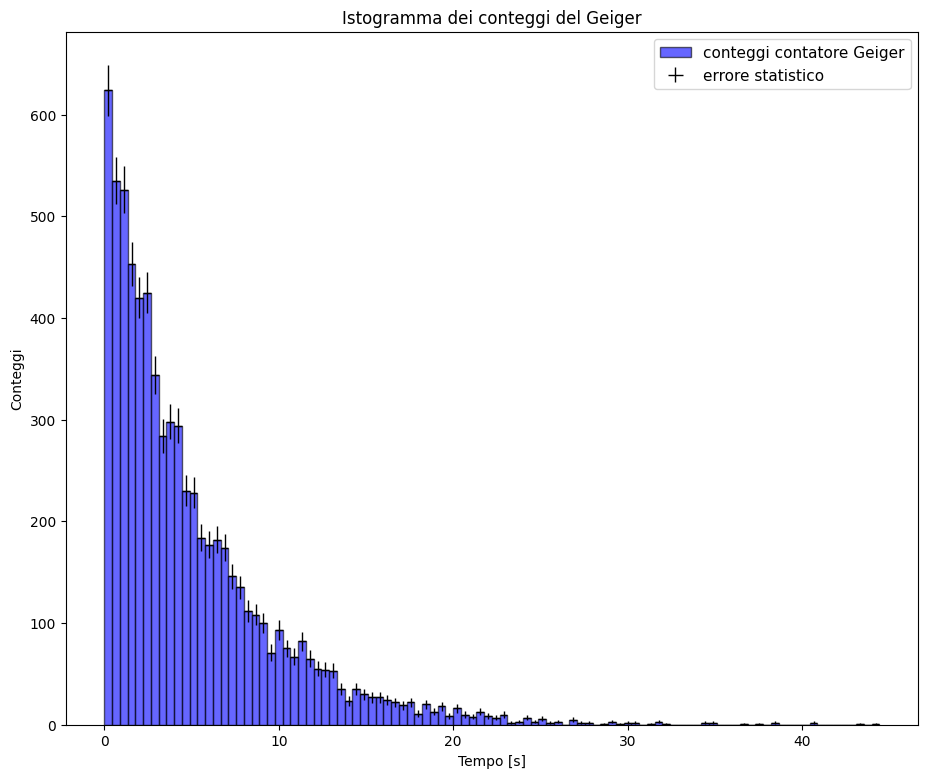

In [838]:
dati = np.loadtxt("conteggi_geiger_terraEtna_notte.txt")
dati = dati/1000

plt.figure(figsize=(11,9))
h, bins, patches = plt.hist(dati, bins=100, alpha=0.6, color='blue', edgecolor = 'black', label = "conteggi contatore Geiger")
larghezza_bin= bins[1]-bins[0]
centri_bin= bins[:-1] + larghezza_bin/2
plt.errorbar(centri_bin, h, np.sqrt(h), larghezza_bin/2, c='tab:grey', lw=1, fmt='none', ecolor='black', label="errore statistico")
plt.xlabel("Tempo [s]")
plt.ylabel("Conteggi")
plt.title(f"Istogramma dei conteggi del Geiger")
plt.legend(loc='best', prop={'size': 11})
plt.show()    

In [839]:
tau_hat= sum(dati)/len(dati)
display(Math(rf"\hat{{\tau}}_{{\mathcal{{L}}}} = {tau_hat} \, s"))
varianza_tau_hat = tau_hat**2/len(dati)
display(Math(rf"\sigma^2_{{\hat{{\tau}}_\mathcal{{L}}}} = {varianza_tau_hat} \,s^2"))
display(Math(rf"\text{{risultato finale}} \hspace{{0.5em}} \hat{{\tau}}_{{\mathcal{{L}}}}  = ({tau_hat:.2f} \pm {np.sqrt(varianza_tau_hat):.2f}) \, s"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### DISTRIBUZIONE DI ERLANG: TEMPO DI ATTESA FRA 2 EVENTI

In [840]:
#valori di indici pari
pari = dati[::2]
#valori di indici dispari
dispari = dati[1::2]
#sommo i dispari ai pari
#nel caso l'array dei pari sia più lungo di quello dei dipari ignoro l'ultimo pari
if(len(pari)>len(dispari)):
    pari = pari[:-1]
risultato = pari+dispari

<IPython.core.display.Math object>

Text(0.5, 1.0, 'Istogramma con curva di distribuzione Erlang')

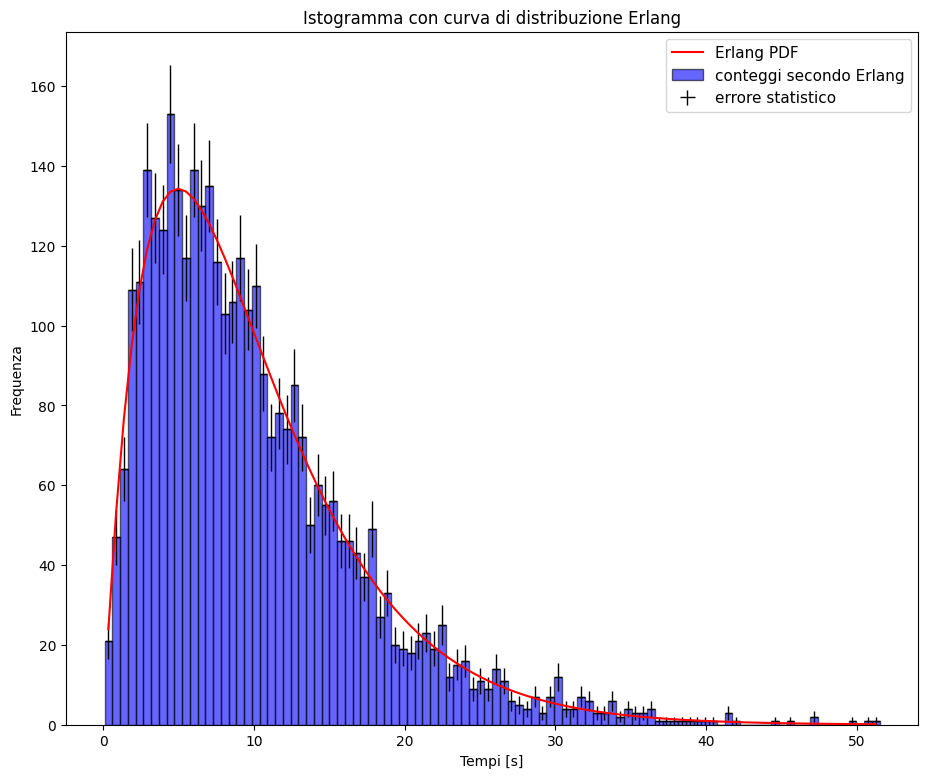

In [841]:
lam = 1/tau_hat
varianza_lam = varianza_tau_hat/(tau_hat**4)
display(Math(rf"\text{{risultato finale  }} \hat{{\lambda}}_{{\mathcal{{L}}}} = ({lam:.3f} \pm {np.sqrt(varianza_lam):.3f}) \, s^{{-1}}"))
plt.figure(figsize=(11,9))
h2, bin_edges = np.histogram(risultato, bins=100)
delta_x2 = bin_edges[1] - bin_edges[0]
centri2 = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(centri2, h2, width=delta_x2, color='blue',  alpha=0.6, edgecolor = 'black', label = 'conteggi secondo Erlang')
plt.errorbar(centri2, h2, yerr=np.sqrt(h2), xerr=delta_x2/2, fmt='none',  ecolor='black', lw=1, label='errore statistico')
plt.plot(centri2, Erlang_pdf(centri2, 2, lam) *len(risultato)*delta_x2 ,color='red', label='Erlang PDF')
plt.legend(loc='best', prop={'size': 11})
plt.xlabel('Tempi [s]')
plt.ylabel('Frequenza')
plt.title(f'Istogramma con curva di distribuzione Erlang')

Text(0.5, 1.0, 'Log-likelihood in funzione di lambda')

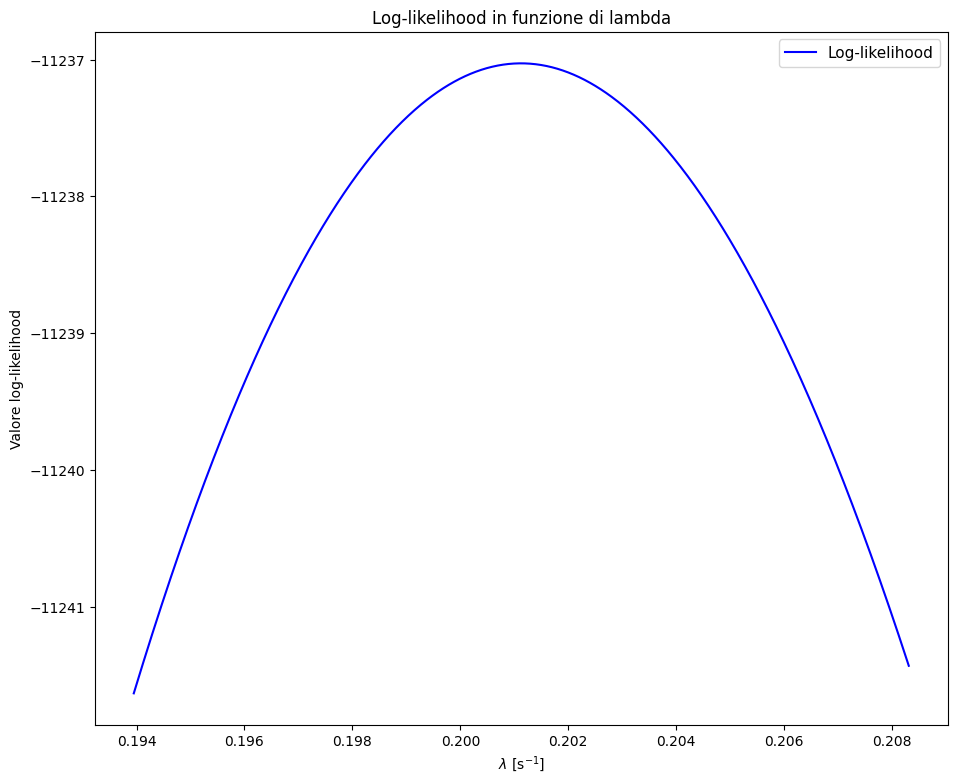

In [842]:
valori_lam = np.linspace(lam-3*np.sqrt(varianza_lam), lam + 3*np.sqrt(varianza_lam), 1000)
val_log_likelihood = [log_likelihood_binned(h2, centri2, lam) for lam in valori_lam]
plt.figure(figsize=(11,9))
plt.plot(valori_lam, val_log_likelihood, color='blue', label='Log-likelihood')
plt.xlabel(r'$\lambda$ [s$^{-1}$]')
plt.ylabel('Valore log-likelihood')
plt.legend(loc='best', prop={'size': 11})
plt.title(f'Log-likelihood in funzione di lambda')

In [843]:
for i in range(len(valori_lam)):
    if val_log_likelihood[i] > val_log_likelihood[i+1]:
        max_log_likelihood = valori_lam[i]
        valore_max = val_log_likelihood[i]
        print(f"Massimo log-likelihood: {valori_lam[i]:.4f} con valore: {val_log_likelihood[i]:.4f}")
        break
    else:
        continue

Massimo log-likelihood: 0.2011 con valore: -11237.0279


In [ ]:
valori_lam_mezzo = []

likelihood_val = valore_max - 0.5
tolleranza = 0.01

for i in range(len(valori_lam)):
    if abs(val_log_likelihood[i] - likelihood_val) < tolleranza:
        print(f"valore vicino a log_likelihood -1/2: {valori_lam[i]:.4f}")
        display(
            Math(
                rf"\text{{valori}} \lambda \text{{vicino a}} \ln(\mathcal{{L}}(\lambda)) - \frac{{1}}{{2}} = ({valori_lam[i]:.3f} \, s^{{-1}})"
            )
        )
        valori_lam_mezzo.append(valori_lam[i])
        
    if len(valori_lam_mezzo) == 5:
        break

print(f"Valori di lambda trovati: {[f'{x:.4f}' for x in valori_lam_mezzo]}")

SyntaxError: f-string: single '}' is not allowed (3010325230.py, line 9)

Sigma di lambda: 0.0024


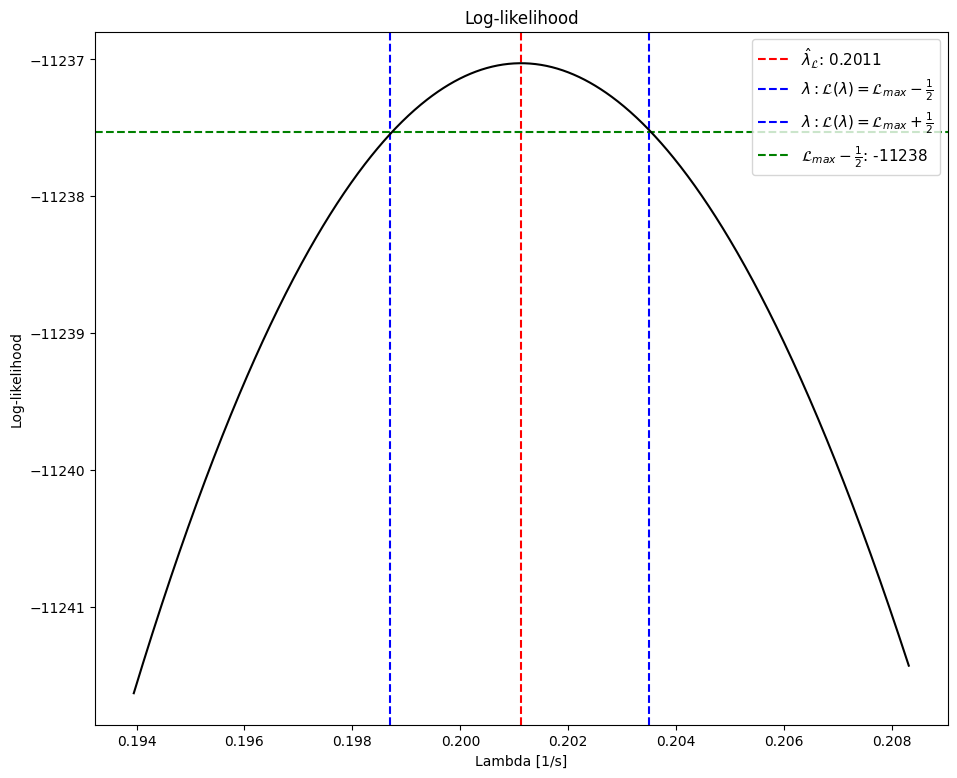

In [ ]:
plt.figure(figsize=(11,9))
plt.axvline(max_log_likelihood, color='red', linestyle='--', label=r'$\hat{\lambda}_\mathcal{L}$:' + f' {max_log_likelihood:.4f}')
plt.axvline(0.1987, color='blue', linestyle='--', label=r'$\lambda: \mathcal{L}(\lambda) = \mathcal{L}_{max} - \frac{1}{2}$' )
plt.axvline(0.2035, color='blue', linestyle='--', label=r'$\lambda: \mathcal{L}(\lambda) = \mathcal{L}_{max} + \frac{1}{2}$' )
plt.axhline(valore_max - 0.5, color='green', linestyle='--', label=r'$\mathcal{L}_{max} - \frac{1}{2}$'+ f': {valore_max - 0.5:.0f}')
plt.plot(valori_lam, val_log_likelihood, color='black')
plt.title("Log-likelihood")
plt.xlabel("Lambda [1/s]")
plt.ylabel("Log-likelihood")
plt.legend(loc='best', prop={'size': 11})
sigma_lam = 0.2035 - max_log_likelihood
print(f"Sigma di lambda: {sigma_lam:.4f}")

Text(0.5, 1.0, 'Chi-squared in funzione di lambda')

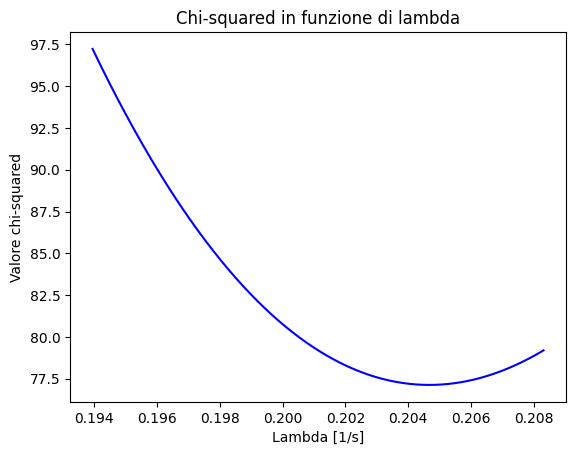

In [ ]:
mask = h2 > 0
h1 = h2[mask]
centri1 = centri2[mask]
val_chi_squared = [chi_squared_binned(h1, centri1, len(risultato), lam, delta_x2) for lam in valori_lam]
plt.plot(valori_lam, val_chi_squared, color='blue')
plt.xlabel('Lambda [1/s]')
plt.ylabel('Valore chi-squared')
plt.title(f'Chi-squared in funzione di lambda')


In [ ]:
for i in range(len(valori_lam)):
    if val_chi_squared[i] < val_chi_squared[i+1]:
        print(f"Minimo chi-squared: {valori_lam[i]:.4f} con valore: {val_chi_squared[i]:.4f}")
        min_chi_squared = valori_lam[i]
        valore_min = val_chi_squared[i]
        break
    else:
        continue

Minimo chi-squared: 0.2047 con valore: 77.1234


In [ ]:
valori_chi_uno = []

chi_val = valore_min + 1
tolleranza = 0.02

for i in range(len(valori_lam)):
    if abs(val_chi_squared[i] - chi_val) < tolleranza:
        print(f"valore vicino a chi-squared +1: {valori_lam[i]:.4f}")
        valori_chi_uno.append(valori_lam[i])
        
    if len(valori_chi_uno) == 5:
        break

print(f"Valori di chi-squared trovati: {[f'{x:.4f}' for x in valori_chi_uno]}")

valore vicino a chi-squared +1: 0.2022
valore vicino a chi-squared +1: 0.2022
valore vicino a chi-squared +1: 0.2022
valore vicino a chi-squared +1: 0.2072
valore vicino a chi-squared +1: 0.2072
Valori di chi-squared trovati: ['0.2022', '0.2022', '0.2022', '0.2072', '0.2072']


Sigma di lambda: 0.0025


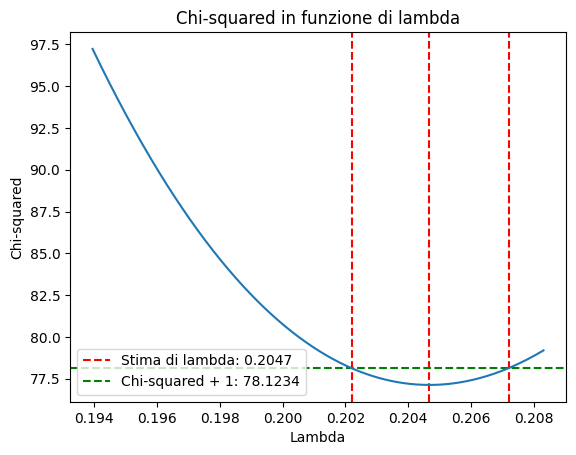

In [ ]:
plt.axvline(min_chi_squared, color='red', linestyle='--', label=f'Stima di lambda: {min_chi_squared:.4f}')
plt.axvline(0.2022, color='red', linestyle='--')
plt.axvline(0.2072, color='red', linestyle='--')
plt.axhline(valore_min + 1, color='green', linestyle='--', label=f'Chi-squared + 1: {valore_min + 1:.4f}')
plt.plot(valori_lam, val_chi_squared)
plt.title("Chi-squared in funzione di lambda")
plt.xlabel("Lambda")
plt.ylabel("Chi-squared")
plt.legend()
sigma_lam = 0.2072 - min_chi_squared
print(f"Sigma di lambda: {sigma_lam:.4f}")

In [ ]:
red = valore_min / (len(h1)-2)
print(f"Reduzione di chi-squared per punto: {red:.4f}")

Reduzione di chi-squared per punto: 0.9073


### TERZA PARTE

In [ ]:
delta_t = 30
lam=lam*30

tcum = np.cumsum(dati)
tmin = 0
tmax = tcum[-1]

print(f"totale tempo trascorso {tmax}")

#creo un vettore di finestre a passi di delta_t che userò come tempo di inizio delle mie finestre temporali
w = np.arange(tmin,tmax,delta_t)
print(f"Tempo di inizio delle finestre temporali che userò: {w}")

#controllo se l'ultima finestra temporale è stata conclusa:
if (tmax<w[-1]+delta_t):
    print("Tolgo l'ultima finestra")
    w = w[:-1]

#faccio un loop sulle finestre
Poisson_counts = []

for i in w:
    #verifico se in ogni finestra ho conteggi 
    ind = np.where((tcum>=i) & (tcum<=(i+delta_t)))
    Poisson_counts.append(len(tcum[ind]))

print(f"\nI conteggi della mia Poisson sono {len(Poisson_counts)}")    

totale tempo trascorso 35116.762999999875
Tempo di inizio delle finestre temporali che userò: [0.000e+00 3.000e+01 6.000e+01 ... 3.504e+04 3.507e+04 3.510e+04]
Tolgo l'ultima finestra

I conteggi della mia Poisson sono 1170


Text(0.5, 1.0, 'Istogramma con curva di distribuzione di Poisson')

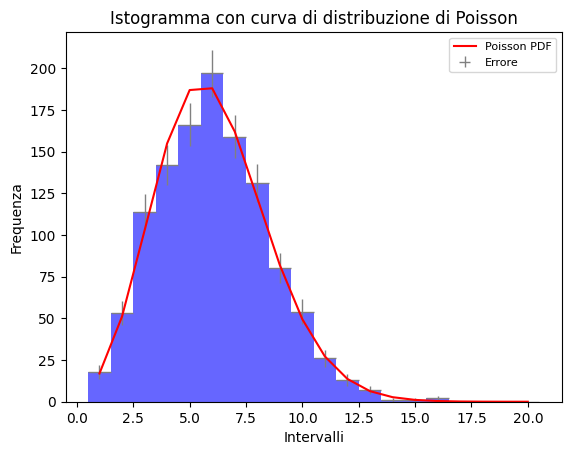

In [ ]:
h, bin_edges = np.histogram(Poisson_counts, bins=20, range=(0.5,20.5))
delta_x = bin_edges[1] - bin_edges[0]
centri = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(centri, h, width=delta_x, color='blue',  alpha=0.6)
plt.errorbar(centri, h, yerr=np.sqrt(h), xerr=delta_x/2, fmt='none', color='grey', lw=1, label='Errore')
plt.plot(centri, Poisson_pdf(lam, centri) *len(Poisson_counts)*delta_x ,color='red', label='Poisson PDF')
plt.legend(fontsize=8)
plt.xlabel('Intervalli')
plt.ylabel('Frequenza')
plt.title(f'Istogramma con curva di distribuzione di Poisson')

In [ ]:
var_lam = varianza_lam * 30**2
sigma_lam = np.sqrt(var_lam)
valori_lam = np.linspace(lam-3*sigma_lam, lam + 3*sigma_lam, 1000)
val_log_likelihood = [log_likelihood_binned2(h, centri, lam) for lam in valori_lam]

for i in range(len(valori_lam)):
    if val_log_likelihood[i] > val_log_likelihood[i+1]:
        print(f"Massimo log-likelihood: {valori_lam[i]:.4f} con valore: {val_log_likelihood[i]:.4f}")
        max_log_likelihood = valori_lam[i]
        valore_max = val_log_likelihood[i]
        break
    else:
        continue

Massimo log-likelihood: 6.0660 con valore: -2686.7619


In [ ]:
valori_lam_mezzo = []

likelihood_val = valore_max - 0.5
tolleranza = 0.01

for i in range(len(valori_lam)):
    if abs(val_log_likelihood[i] - likelihood_val) < tolleranza:
        print(f"valore vicino a log_likelihood -1/2: {valori_lam[i]:.4f}")
        valori_lam_mezzo.append(valori_lam[i])
        
    if len(valori_lam_mezzo) == 5:
        break

print(f"Valori di lambda trovati: {[f'{x:.4f}' for x in valori_lam_mezzo]}")

valore vicino a log_likelihood -1/2: 5.9936
valore vicino a log_likelihood -1/2: 5.9940
valore vicino a log_likelihood -1/2: 5.9944
valore vicino a log_likelihood -1/2: 5.9948
valore vicino a log_likelihood -1/2: 6.1380
Valori di lambda trovati: ['5.9936', '5.9940', '5.9944', '5.9948', '6.1380']


Sigma di lambda: 0.0724


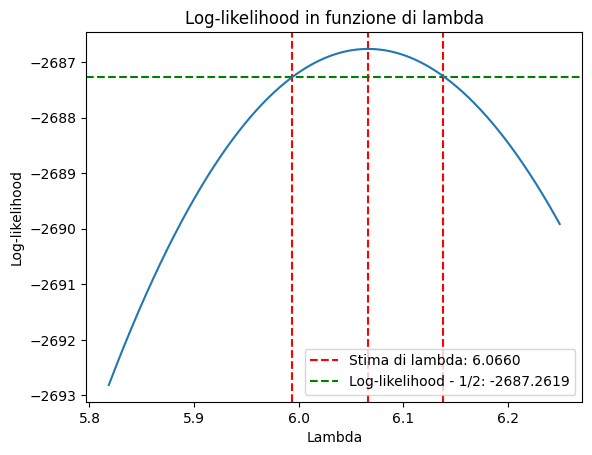

In [ ]:
plt.axvline(max_log_likelihood, color='red', linestyle='--', label=f'Stima di lambda: {max_log_likelihood:.4f}')
plt.axvline(5.9936, color='red', linestyle='--')
plt.axvline(6.1380, color='red', linestyle='--')
plt.axhline(valore_max - 0.5, color='green', linestyle='--', label=f'Log-likelihood - 1/2: {valore_max - 0.5:.4f}')
plt.plot(valori_lam, val_log_likelihood)
plt.title("Log-likelihood in funzione di lambda")
plt.xlabel("Lambda")
plt.ylabel("Log-likelihood")
plt.legend()

sigma_lam = max_log_likelihood - 5.9936
print(f"Sigma di lambda: {sigma_lam:.4f}")

In [ ]:
mask= h>0
h1 = h[mask]
centri1 = centri[mask]
val_chi_squared = [chi_squared_binned2(h1, len(Poisson_counts), lam, centri1, delta_x) for lam in valori_lam]

for i in range(len(valori_lam)):
    if val_chi_squared[i] < val_chi_squared[i+1]:
        print(f"Minimo chi-squared: {valori_lam[i]:.4f} con valore: {val_chi_squared[i]:.4f}")
        min_chi_squared = valori_lam[i]
        valore_min = val_chi_squared[i]
        break
    else:
        continue

Minimo chi-squared: 6.0272 con valore: 10.9376


In [ ]:
valori_chi_uno = []

chi_val = valore_min + 1
tolleranza = 0.02

for i in range(len(valori_lam)):
    if abs(val_chi_squared[i] - chi_val) < tolleranza:
        print(f"valore vicino a chi-squared +1: {valori_lam[i]:.4f}")
        valori_chi_uno.append(valori_lam[i])
        
    if len(valori_chi_uno) == 5:
        break

print(f"Valori di chi-squared trovati: {[f'{x:.4f}' for x in valori_chi_uno]}")

valore vicino a chi-squared +1: 5.9552
valore vicino a chi-squared +1: 5.9556
valore vicino a chi-squared +1: 5.9560
valore vicino a chi-squared +1: 6.0979
valore vicino a chi-squared +1: 6.0983
Valori di chi-squared trovati: ['5.9552', '5.9556', '5.9560', '6.0979', '6.0983']


Sigma di lambda: 0.0720


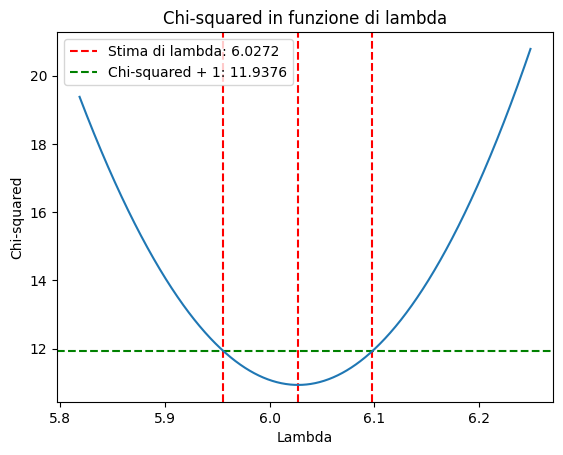

In [ ]:
plt.axvline(min_chi_squared, color='red', linestyle='--', label=f'Stima di lambda: {min_chi_squared:.4f}')
plt.axvline(5.9552, color='red', linestyle='--')
plt.axvline(6.0979, color='red', linestyle='--')
plt.axhline(valore_min + 1, color='green', linestyle='--', label=f'Chi-squared + 1: {valore_min + 1:.4f}')
plt.plot(valori_lam, val_chi_squared)
plt.title("Chi-squared in funzione di lambda")
plt.xlabel("Lambda")
plt.ylabel("Chi-squared")
plt.legend()
sigma_lam = min_chi_squared- 5.9552  
print(f"Sigma di lambda: {sigma_lam:.4f}")

In [ ]:
red = valore_min / (len(h1)-2)
print(f"Chi-squared ridotto {red:.4f}")
red2=np.sqrt((2*valore_min)/(2*(len(h1)-2)-1))
print(f"Chi-squared ridotto, corretto: {red2:.4f}")

Chi-squared ridotto 0.7813
Chi-squared ridotto, corretto: 0.9001


### QUARTA PARTE

In [ ]:
mask = h2 > 5 
mask_2 = h > 5
h1 = h2[mask]
centri1 = centri2[mask]
h = h[mask_2]
centri = centri[mask_2]

In [ ]:
val_chi = chi_squared_binned_erlang(h1, centri1, len(risultato),  0.2047 , delta_x2)
print(f"Chi-squared per Erlang: {val_chi:.4f}")

val_chi_poisson = chi_squared_binned_poisson(h, len(Poisson_counts), 6.0272, centri, delta_x)
print(f"Chi-squared per Poisson: {val_chi_poisson:.4f}")

Chi-squared per Erlang: 71.7646
Chi-squared per Poisson: 6.5924


In [ ]:
alpha = 0.05
print("Significatività dei test di chi-squared per Erlang")

chi2_m1 = val_chi
ndf1 = len(h1) - 2 

print("Chi2 minimo:",chi2_m1)
print("Numero di gradi di libertà",ndf1)

p_value = chi2.sf(chi2_m1, ndf1)
print("p value:",p_value)

if (p_value>alpha):
    print("Non posso rigettare l'ipotesi!")
else:
    print("Devo rigettare l'ipotesi!")

print("\n\n\n")

chi2_s = chi2.isf(alpha, ndf1)
print("Chi quadro di soglia",chi2_s)

if (chi2_m1<chi2_s):
    print("Non posso rigettare l'ipotesi!")
else:
    print("Devo rigettare l'ipotesi!")

print("\n\n\n")

print("Significatività dei test di chi-squared per Poisson")
chi2_m2 = val_chi_poisson
ndf2 = len(h) - 2
print("Chi2 minimo:",chi2_m2)
print("Numero di gradi di libertà",ndf2)

chi2_s = chi2.isf(alpha, ndf2)
print("Chi quadro di soglia",chi2_s)

if (chi2_m2<chi2_s):
    print("Non posso rigettare l'ipotesi!")
else:
    print("Devo rigettare l'ipotesi!")

print("\n\n\n")


p_value = chi2.sf(chi2_m2, ndf2)
print("p value:",p_value)

if (p_value>alpha):
    print("Non posso rigettare l'ipotesi!")
else:
    print("Devo rigettare l'ipotesi!")


Significatività dei test di chi-squared per Erlang
Chi2 minimo: 71.76461378068855
Numero di gradi di libertà 57
p value: 0.09012233064776701
Non posso rigettare l'ipotesi!




Chi quadro di soglia 75.62374846937605
Non posso rigettare l'ipotesi!




Significatività dei test di chi-squared per Poisson
Chi2 minimo: 6.592414600032277
Numero di gradi di libertà 11
Chi quadro di soglia 19.67513757268249
Non posso rigettare l'ipotesi!




p value: 0.8310654708196112
Non posso rigettare l'ipotesi!
